In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

sys.path.append('src')
plt.style.use('ggplot')

from utils import compute_t_stat

# Statistical Inference of Two Populations

In the previous notebooks, we worked with a single population. However, to find evidence, we often have to work with more than one group. In this notebook, we will look at the statistical methods that are used when comparing two groups.

## Statistical Inference Using Bootstrap Sampling


### Confidence Intervals with Point Estimates

#### Paired Samples

**Example 1**

Let's say we want to find evidence about the effectiveness of a new treatment by comparing cholesterol levels in the same group of individuals under two conditions: one month with treatment and one month without treatment (control).

This is a paired experiment setup. We can apply bootstrap sampling in the following way:

* Subtract treatment and control group results from each other so the problem becomes a one-sample problem.
* Sample repeatedly with replacement to obtain a difference distribution.
* See whether 0 is in the confidence interval. If it is, then conclude that more evidence is needed to show that this new treatment is effective.

$H_0: \mu_{diff} = 0$

$H_1: \mu_{diff} \neq 0$


ConfidenceInterval(low=np.float64(-7.374056241119226), high=np.float64(-3.0338954436866685))


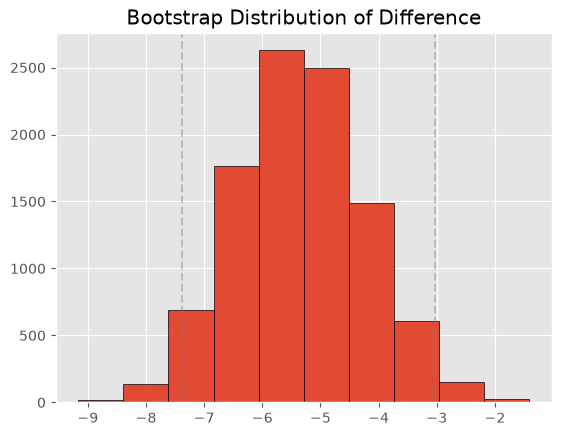

In [2]:
np.random.seed(42)
cholesterol_treatment = np.random.normal(loc = 200, scale = 5, size = 30)
cholesterol_control = np.random.normal(loc = 205, scale = 5, size = 30)

diff = cholesterol_treatment - cholesterol_control
boots = stats.bootstrap((diff,),statistic = np.mean,random_state = 42)

print(boots.confidence_interval)
plt.figure()
plt.hist(boots.bootstrap_distribution,edgecolor = 'black',bins = 10)
plt.axvline(x = boots.confidence_interval.low, color = 'grey', alpha = 0.4,linestyle = "--")
plt.axvline(x = boots.confidence_interval.high, color = 'grey', alpha = 0.4,linestyle = "--")
plt.title("Bootstrap Distribution of Difference")
plt.show()

0 is not in the confidence interval, therefore:

* We are 95% confident that the new treatment is effective.

Alternatively, we can use the code below:

In [3]:
boots = stats.bootstrap((cholesterol_treatment,cholesterol_control),statistic = lambda x,y: np.mean(x) - np.mean(y),random_state = 42,
                        paired = True)
print(boots.confidence_interval)

ConfidenceInterval(low=np.float64(-7.374056241119214), high=np.float64(-3.0338954436866703))


#### Independent Samples

Now suppose that we are comparing two *independent* samples. To compare groups with bootstrapping, we will use the following procedure:

* Sample from both groups repeatedly with replacement.
* Subtract the point estimates from each other.
* Repeat the previous two steps many times to obtain a Gaussian distribution.
* Make inferences.

**Example 2**

Comparing the cumulative GPA of schools A and B:

School A: $\mu_a = 10$, $\sigma_a = 5$, $n_a = 30$

School B: $\mu_b = 9$, $\sigma_b = 5$, $n_b = 30$

$H_0: \mu_a = \mu_b$

$H_1: \mu_a \neq \mu_b$


(-1.6175461990267708, 2.9156933554800153)


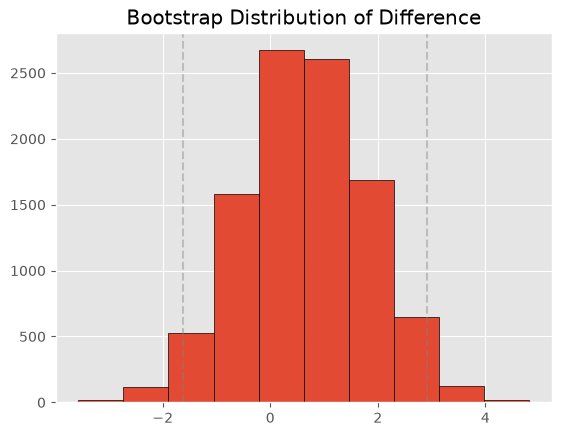

In [4]:
np.random.seed(42)

school_a_cpga = np.random.normal(loc = 10, scale = 5, size = 30)
school_b_cpga = np.random.normal(loc = 9, scale = 5, size = 30)

n_simulations = 10000
diff = []

for _ in range(n_simulations):
    sample_a = np.random.choice(school_a_cpga,size = len(school_a_cpga),replace = True)
    sample_b = np.random.choice(school_b_cpga,size = len(school_b_cpga),replace = True)
    diff.append(np.mean(sample_a) - np.mean(sample_b))

diff = np.array(diff)
print(f'({np.percentile(diff,2.5)}, {np.percentile(diff,97.5)})')
plt.figure()
plt.hist(diff,edgecolor = 'black',bins = 10)
plt.axvline(x = np.percentile(diff,2.5), color = 'grey', alpha = 0.4,linestyle = "--")
plt.axvline(x = np.percentile(diff,97.5), color = 'grey', alpha = 0.4,linestyle = "--")
plt.title("Bootstrap Distribution of Difference")
plt.show()

Since 0 is in our confidence interval:

* We can't say that the grades of the students are different from each other.

What we have just done is equivalent to bootstrapping first and getting the difference afterwards:


(-1.5925218233237843, 2.9580462265027387)


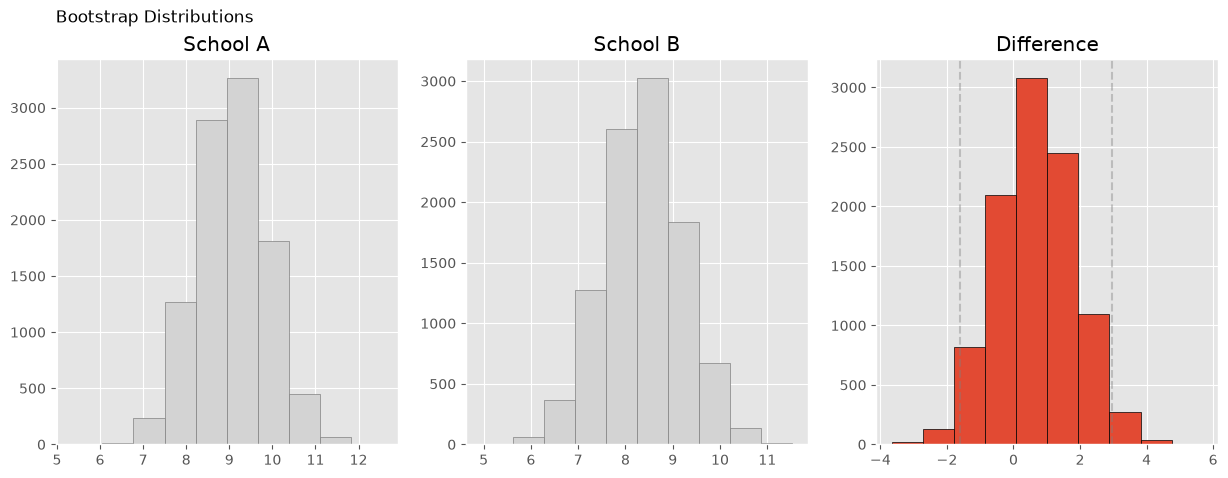

In [5]:
np.random.seed(42)

boot_means_a = [np.mean(np.random.choice(school_a_cpga, 30, replace = True)) for _ in range(10000)]
boot_means_b = [np.mean(np.random.choice(school_b_cpga, 30, replace = True)) for _ in range(10000)]
diff = np.array(boot_means_a) - np.array(boot_means_b)

print(f'({np.percentile(diff,2.5)}, {np.percentile(diff,97.5)})')
fig, ax = plt.subplots(ncols = 3, nrows = 1, figsize = (15,5))

ax[0].hist(boot_means_a, edgecolor = 'grey', bins = 10, color = 'lightgrey')
ax[1].hist(boot_means_b, edgecolor = 'grey', bins = 10, color = 'lightgrey')
ax[2].hist(diff, edgecolor = 'black', bins = 10)

ax[0].set_title('School A')
ax[1].set_title('School B')
ax[2].set_title('Difference')

ax[2].axvline(x = np.percentile(diff,2.5), color = 'grey', alpha = 0.4, linestyle = "--")
ax[2].axvline(x = np.percentile(diff,97.5), color = 'grey', alpha = 0.4, linestyle = "--")

fig.suptitle("Bootstrap Distributions", fontsize = 12, x = 0.125, ha = 'left')
plt.show()


Alternatively, we can use the following code:


In [6]:
boots = stats.bootstrap((school_a_cpga,school_b_cpga),
                        statistic = lambda x,y: np.mean(x) - np.mean(y),
                        random_state = 42,
                        paired = False)
print(boots.confidence_interval)

ConfidenceInterval(low=np.float64(-1.562673653014612), high=np.float64(2.967970323506545))


### Confidence Intervals with T-Percentiles

As an alternative to the previous solution, we can use the t-statistic bootstrap distribution to compute CI. For independent samples, we will use the more robust form for samples having different variances:

$SE = \sqrt{\frac {s_1^2} {n_1} + \frac {s_2^2} {n_2}}$

and the corresponding bootstrap t-value $(t^*)$ will be:

$t^* = \frac {(\bar{x}_1^* - \bar{x}_2^*) - (\bar{x}_1 - \bar{x}_2)} {SE^*}$

where $\bar{x}_i^*$ and $\bar{x}_i$ denote the bootstrap mean and the sample mean respectively. Subtracting the observed difference centers the $t^*$ distribution around 0.

Now that the definitions are clear, we can continue with the procedure:

* Compute the observed difference $(\bar{x}_1 - \bar{x}_2)$ and its standard error $(SE)$.
* Sample repeatedly from the groups.
* Compute the t-statistic $(t^*)$ each time and record the value in a list.
* Get appropriate percentiles of the t-distribution and convert them back to the difference scale:

$\left( (\bar{x}_1 - \bar{x}_2) - t^*_{0.975} \cdot SE, \quad (\bar{x}_1 - \bar{x}_2) - t^*_{0.025} \cdot SE \right)$

Note that the upper percentile gives the lower bound.


In [7]:
np.random.seed(42)

school_a_cpga = np.random.normal(loc = 10, scale = 5, size = 30)
school_b_cpga = np.random.normal(loc = 9, scale = 5, size = 30)

observed_diff = np.mean(school_a_cpga) - np.mean(school_b_cpga)
observed_se = np.sqrt(np.var(school_a_cpga, ddof = 1) / len(school_a_cpga) +
                      np.var(school_b_cpga, ddof = 1) / len(school_b_cpga))

num_iterations = 10000
t_stats = []

for _ in range(num_iterations):
    sample_a = np.random.choice(school_a_cpga,size = len(school_a_cpga),replace = True)
    sample_b = np.random.choice(school_b_cpga,size = len(school_b_cpga),replace = True)
    t_stats.append(compute_t_stat(sample_a,sample_b,center = observed_diff))

t_stats = np.array(t_stats)
t_low, t_high = np.percentile(t_stats,2.5), np.percentile(t_stats,97.5)

ci_low = observed_diff - t_high * observed_se
ci_high = observed_diff - t_low * observed_se

print(f'({ci_low}, {ci_high})')


(-1.6368416113982605, 3.087236929791498)


0 is in the confidence interval, therefore:

* We can't say that the two groups are different from each other.

This agrees with the previous bootstrap-based confidence interval.


## Statistical Inference with Analytical Methods

### Paired T-Test

Let's go back to Example 1. This time we will compare the groups using a paired t-test. Before using it, the following assumptions have to be met:

* The pairs are independent from each other.
* The differences between paired observations are approximately normally distributed.

Unlike the independent-samples t-test, equal variances are not required here.

We know the pairs are independent. Let's verify the second assumption by checking the distribution of the differences.


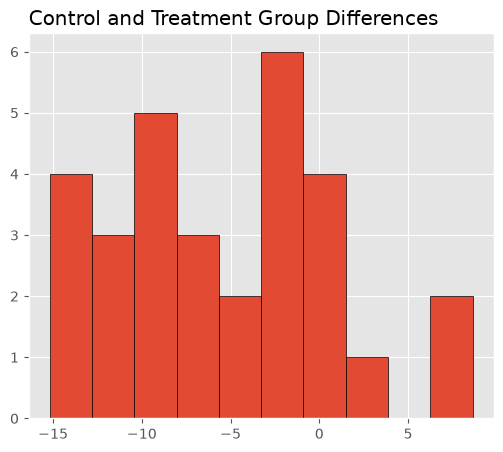

In [8]:
np.random.seed(42)
cholesterol_treatment = np.random.normal(loc = 200, scale = 5, size = 30)
cholesterol_control = np.random.normal(loc = 205, scale = 5, size = 30)

diff = cholesterol_treatment - cholesterol_control

fig,ax = plt.subplots(figsize = (6,5))
ax.hist(diff,edgecolor = 'black')
ax.set_title('Control and Treatment Group Differences',loc = 'left')
plt.show()


The distribution of the differences is somewhat normal (there are no extreme points). Don't forget, we are not searching for a perfect normality condition. The paired t-test is robust enough to handle these imperfections.

Since this is a paired t-test, we do not need to compare the variances of the two groups.

For the test statistic, we can write:

All the conditions for the paired t-test are met. For paired samples,

$d = d_1, d_2, \ldots, d_n$ where $d$ refers to the pair differences.

$s_d$: Standard deviation of the differences.

$SE_d = \frac {s_d} {\sqrt{n}}\quad$: Standard error

$t = \frac {\bar{d}} {SE_d}$


In [9]:
diff = cholesterol_treatment - cholesterol_control
se_diff = np.std(diff,ddof = 1) / np.sqrt(len(diff))
t_diff = np.mean(diff) / se_diff
t_diff

np.float64(-4.753798870455525)

We can look at a t-table to find the p-value. Alternatively, we can use `ttest_rel`.

In [10]:
ttest_result = stats.ttest_rel(cholesterol_treatment,cholesterol_control)
print(ttest_result)

TtestResult(statistic=np.float64(-4.753798870455525), pvalue=np.float64(5.026835945729069e-05), df=np.int64(29))


The p-value is smaller than the p-critical (0.05). Hence, we can conclude that the means of the two groups are different from each other. ($p < p_{critical} = 0.05$)

### Independent T-Test

Let's go back to Example 2. This time we will compare the groups using an independent t-test. Before using it, the following assumptions have to be met:

* The two samples are independent from each other.
* Each group is approximately normally distributed (or the sample sizes are large enough for the CLT to apply).

Unlike the paired t-test, we also need to check whether the two groups have equal variances, since this changes how the standard error is computed. Since $\sigma_a = \sigma_b = 5$, we will use the pooled (equal variances) version of the test.

$s_p^2 = \frac {(n_1-1)s_1^2 + (n_2-1)s_2^2} {n_1+n_2-2} \quad$: Pooled variance

$SE = s_p \sqrt{\frac {1} {n_1} + \frac {1} {n_2}} \quad$: Standard error

$t = \frac {\bar{x}_1 - \bar{x}_2} {SE}\quad$, with $df = n_1 + n_2 - 2$


In [11]:
np.random.seed(42)

school_a_cpga = np.random.normal(loc = 10, scale = 5, size = 30)
school_b_cpga = np.random.normal(loc = 9, scale = 5, size = 30)

n_a, n_b = len(school_a_cpga), len(school_b_cpga)
s_a, s_b = np.std(school_a_cpga, ddof = 1), np.std(school_b_cpga, ddof = 1)

s_pooled = np.sqrt(((n_a - 1) * s_a**2 + (n_b - 1) * s_b**2) / (n_a + n_b - 2))
se = s_pooled * np.sqrt(1/n_a + 1/n_b)
t_statistic = (np.mean(school_a_cpga) - np.mean(school_b_cpga)) / se

df = n_a + n_b - 2
p_value = 2 * (1 - stats.t.cdf(np.abs(t_statistic), df))

print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.4f}")

t-statistic: 0.5626
p-value: 0.5759


We can look at a t-table to find the p-value. Alternatively, we can use `ttest_ind`.

In [12]:
ttest_result = stats.ttest_ind(school_a_cpga, school_b_cpga, equal_var = True)
print(ttest_result)

TtestResult(statistic=np.float64(0.562602163541992), pvalue=np.float64(0.5758740364448268), df=np.float64(58.0))


The p-value is greater than the p-critical (0.05). Hence, we can't say that the means of the two groups are different from each other. ($p > p_{critical} = 0.05$)

This agrees with the earlier bootstrap-based confidence interval, where 0 was inside the interval.

Before moving to the next section, let's see what the t-test does visually:


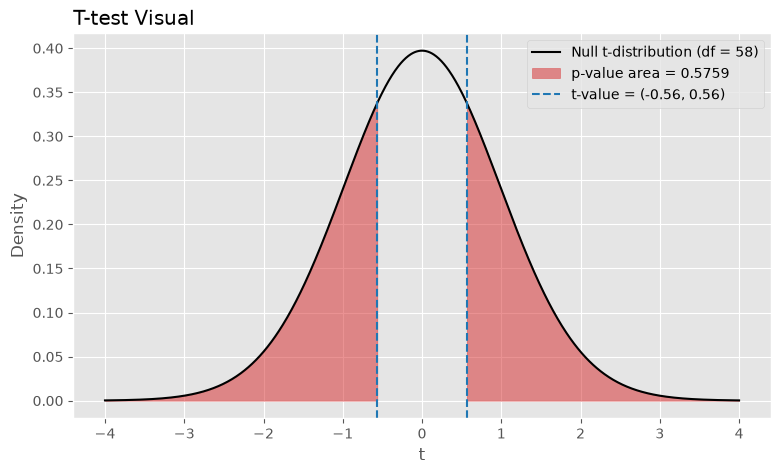

In [13]:
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df)

fig, ax = plt.subplots(figsize = (9,5))
ax.plot(x, y, color = 'black', label = f'Null t-distribution (df = {df})')

# Two-sided p-value corresponds to both tails beyond |t|
ax.fill_between(x, y, where = x >= np.abs(t_statistic), color = 'tab:red', alpha = 0.5)
ax.fill_between(x, y, where = x <= -np.abs(t_statistic), color = 'tab:red', alpha = 0.5,
                label = f'p-value area = {p_value:.4f}')

ax.axvline(x = t_statistic, color = 'tab:blue', linestyle = '--',
           label = f't-value = ({-t_statistic:.2f}, {t_statistic:.2f})')
ax.axvline(x = -t_statistic, color = 'tab:blue', linestyle = '--')

ax.set_title('T-test Visual', loc = 'left')
ax.set_xlabel('t')
ax.set_ylabel('Density')
ax.legend()
plt.show()


The distribution above is called the null $(H_0)$ distribution. If the two groups were the same, this is the distribution of standardized differences we would expect to see. The test computes the standardized mean difference (the t-statistic) and excludes the corresponding area under that curve. When the t-statistic is large enough, the p-value area shrinks and we conclude that the difference is statistically significant.


### Permutation Tests

Permutation tests are extremely useful when working with small sample sizes. We use these tests to determine whether an observed difference in point estimates is due to chance. Here are the steps:

* Record the observed difference in point estimates.
* Repeat the following many times:
    * Combine and shuffle the data.
    * Distribute the data to the groups randomly.
    * Check whether the absolute value of the iteration difference is larger than the absolute value of the observed difference. (Assuming the test is two-sided)
* Count how many times the iteration difference exceeds the observed difference.
* Depending on the desired confidence level, evaluate the results.

**Example 3**

Sample A: $\mu_a = 10$, $\sigma_a = 5$, $n_a = 10$

Sample B: $\mu_b = 9$, $\sigma_b = 5$, $n_b = 10$

$H_0: \mu_a = \mu_b$

$H_1: \mu_a \neq \mu_b$


p-value: 0.0003


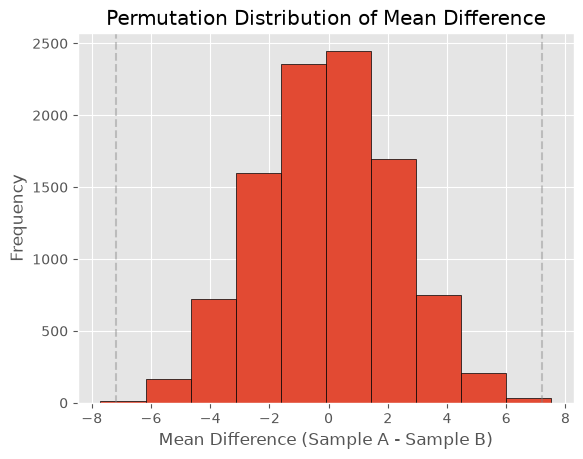

In [14]:
np.random.seed(42)
sample_a = np.random.normal(loc = 10, scale = 5, size = 10)
sample_b = np.random.normal(loc = 9, scale = 5, size = 10)
observational_difference = np.mean(sample_a) - np.mean(sample_b)
p_value = 0

n_simulations = 10000
iteration_differences = []

for _ in range(n_simulations):
    combined_sample = np.concatenate((sample_a,sample_b))
    np.random.shuffle(combined_sample)
    sample_a_temp = combined_sample[:len(sample_a)]
    sample_b_temp = combined_sample[len(sample_a):]
    iter_difference = np.mean(sample_a_temp) - np.mean(sample_b_temp)
    iteration_differences.append(iter_difference)
    if np.abs(iter_difference) >= np.abs(observational_difference):
        p_value += 1

p_value /= n_simulations
print(f"p-value: {p_value}")

plt.figure()
plt.hist(iteration_differences,edgecolor = "black",bins = 10)
plt.axvline(x = observational_difference, color = 'grey', alpha = 0.4,linestyle = "--")
plt.axvline(x = -observational_difference, color = 'grey', alpha = 0.4,linestyle = "--")
plt.title("Permutation Distribution of Mean Difference")
plt.xlabel("Mean Difference (Sample A - Sample B)")
plt.ylabel("Frequency")
plt.show()

The p-value is smaller than the p-critical (0.05). Hence, we can conclude that the means of the two groups are different from each other.

Alternatively, we can use the following code:

In [15]:
results = stats.permutation_test((sample_a,sample_b),
                       statistic = lambda x,y: np.mean(x) - np.mean(y),
                       n_resamples = 10000,
                       alternative = "two-sided",
                       random_state = 42)
results.statistic,results.pvalue

(np.float64(7.193596731405851), np.float64(0.0005999400059994001))

## Evaluating the Importance of the Difference

We saw various ways to compare two groups. Finding something statistically significant does not necessarily imply that it is actually important. Remember the t-statistic:

$t = \frac{\bar{x}_1 - \bar{x}_2}{SE}$

As sample size gets larger and larger, the standard error decreases and the t-statistic increases. Alongside the degrees of freedom, the greater t-statistic yields small p-values even though the difference is not that significant in real life.

To overcome this problem, we use "effect size". The most frequently used one is Cohen's d:

$d = \frac{\bar{x}_1 - \bar{x}_2}{s_{pooled}}$

where

$s_{pooled} = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}}$

For the interpretation we can use the table below:

| Cohen's d | Interpretation |
|-----------|----------------|
| 0.2       | Small effect   |
| 0.5       | Medium effect  |
| 0.8       | Large effect   |

Let's see this on an example.

**Example 4**

Comparing the cumulative GPA of schools A and B:

School A: $\mu_a = 12$, $\sigma_a = 5$, $n_a = 30$

School B: $\mu_b = 9$, $\sigma_b = 5$, $n_b = 30$

$H_0: \mu_a = \mu_b$

$H_1: \mu_a \neq \mu_b$


In [16]:
np.random.seed(42)
school_a_cpga = np.random.normal(loc = 12, scale = 5, size = 30)
school_b_cpga = np.random.normal(loc = 9, scale = 5, size = 30)

n_a, n_b = len(school_a_cpga), len(school_b_cpga)
s_a, s_b = np.std(school_a_cpga, ddof = 1), np.std(school_b_cpga, ddof = 1)

s_pooled = np.sqrt(((n_a - 1) * s_a**2 + (n_b - 1) * s_b**2) / (n_a + n_b - 2))
cohen_d = (np.mean(school_a_cpga) - np.mean(school_b_cpga)) / s_pooled
t_statistic, p_value = stats.ttest_ind(school_a_cpga, school_b_cpga, equal_var = True)

print(f"Pooled std : {s_pooled:.4f}")
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Cohen's d  : {cohen_d:.4f}")


Pooled std : 4.5784
t-statistic: 2.2544
p-value: 0.0280
Cohen's d  : 0.5821


The p-value is smaller than the p-critical (0.05), so we reject $H_0$. The difference between the two schools is statistically significant. On the other hand, $d = 0.58$ tells us that the difference has a medium practical importance.